In [ ]:
# -----------------------------------------------
# Cell 1: Check GPU
# -----------------------------------------------
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else ' No GPU found.')

Tue Apr  7 21:09:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# -----------------------------------------------
# Cell 2: Imports
# -----------------------------------------------
import torch
import torch.nn as nn
from torch.nn import functional as F
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output, display
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [3]:
# -----------------------------------------------
# Cell 3: Hyperparameters
# -----------------------------------------------
batch_size    = 64
block_size    = 256
max_iters     = 5000
eval_interval = 500
learning_rate = 3e-4
device        = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters    = 200
n_embd        = 384
n_head        = 6
n_layer       = 6
dropout       = 0.2

torch.manual_seed(1337)
print(f'Training on: {device.upper()}')

Training on: CUDA


In [4]:
# -----------------------------------------------
# Cell 4: Download dataset (tiny shakespeare)
# -----------------------------------------------
import urllib.request, os

if not os.path.exists('input.txt'):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, 'input.txt')
    print('✅ Downloaded tiny shakespeare dataset')
else:
    print('✅ Dataset already exists')

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Dataset size    : {len(text):,} characters')

chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi       = {ch: i for i, ch in enumerate(chars)}
itos       = {i: ch for i, ch in enumerate(chars)}
encode     = lambda s: [stoi[c] for c in s]
decode     = lambda l: ''.join([itos[i] for i in l])

data       = torch.tensor(encode(text), dtype=torch.long)
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

print(f'Vocab size      : {vocab_size}')
print(f'Train tokens    : {len(train_data):,}')
print(f'Val tokens      : {len(val_data):,}')

✅ Downloaded tiny shakespeare dataset
Dataset size    : 1,115,394 characters
Vocab size      : 65
Train tokens    : 1,003,854
Val tokens      : 111,540


In [5]:
# -----------------------------------------------
# Cell 5: Batch loader
# -----------------------------------------------
def get_batch(split):
    data   = train_data if split == 'train' else val_data
    ix     = torch.randint(len(data) - block_size, (batch_size,))
    x      = torch.stack([data[i:i + block_size] for i in ix])
    y      = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

In [6]:
# -----------------------------------------------
# Cell 6: GPT Model
# -----------------------------------------------
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k   = self.key(x)
        q   = self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v   = self.value(x)
        return wei @ v


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads   = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj    = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),                        # GELU (matches GPT-2)
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks                   = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f                     = nn.LayerNorm(n_embd)
        self.lm_head                  = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T    = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x       = tok_emb + pos_emb
        x       = self.blocks(x)
        x       = self.ln_f(x)
        logits  = self.lm_head(x)
        loss    = None
        if targets is not None:
            B, T, C = logits.shape
            logits  = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss    = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :]
            probs     = F.softmax(logits, dim=-1)
            idx_next  = torch.multinomial(probs, num_samples=1)
            idx       = torch.cat((idx, idx_next), dim=1)
        return idx

In [7]:
# -----------------------------------------------
# Cell 7: Initialize model
# -----------------------------------------------
model     = GPTLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model parameters : {total_params:.2f} M')
print(f'Device           : {device.upper()}')

if device == 'cuda':
    allocated = torch.cuda.memory_allocated() / 1e6
    print(f'GPU memory used  : {allocated:.1f} MB (after model load)')

Model parameters : 10.79 M
Device           : CUDA
GPU memory used  : 52.6 MB (after model load)


In [8]:
# -----------------------------------------------
# Cell 8: Loss estimation helper
# -----------------------------------------------
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y      = get_batch(split)
            _, loss   = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [9]:

# -----------------------------------------------
# Cell 9: Live plot helper
# -----------------------------------------------
def plot_metrics(iters_log, train_losses, val_losses, memories, tokens_log):
    fig = plt.figure(figsize=(16, 10))
    fig.patch.set_facecolor('#0f0f1a')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    axes  = [fig.add_subplot(gs[i, j]) for i, j in [(0,0),(0,1),(1,0),(1,1)]]
    style = dict(facecolor='#1a1a2e', framealpha=0)

    colors = ['#00d4ff', '#ff6b6b', '#a8ff78', '#ffcc02']
    titles = ['Training Loss', 'Validation Loss', 'GPU Memory (MB)', 'Tokens Processed']
    ydatas = [train_losses, val_losses, memories, tokens_log]
    ylabels = ['Loss', 'Loss', 'MB', 'Tokens']

    for ax, color, title, ydata, ylabel in zip(axes, colors, titles, ydatas, ylabels):
        ax.set_facecolor('#1a1a2e')
        for spine in ax.spines.values():
            spine.set_color('#333355')
        ax.tick_params(colors='#aaaacc', labelsize=8)
        ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('Iteration', color='#aaaacc', fontsize=8)
        ax.set_ylabel(ylabel, color='#aaaacc', fontsize=8)
        ax.grid(True, color='#2a2a4a', linewidth=0.5, linestyle='--')
        if ydata:
            ax.plot(iters_log, ydata, color=color, linewidth=2, marker='o',
                    markersize=4, markerfacecolor=color, alpha=0.9)
            ax.fill_between(iters_log, ydata, alpha=0.15, color=color)
        if title in ('Training Loss', 'Validation Loss') and train_losses and val_losses:
            latest_train = train_losses[-1]
            latest_val   = val_losses[-1]
            ax.set_title(
                f'{title}  [latest: {(latest_train if "Train" in title else latest_val):.4f}]',
                color='white', fontsize=10, fontweight='bold', pad=8
            )

    iters_done = iters_log[-1] if iters_log else 0
    fig.suptitle(
        f'GPT-2 Training  |  iter {iters_done}/{max_iters}  |  device: {device.upper()}',
        color='white', fontsize=13, fontweight='bold', y=0.98
    )
    plt.savefig('training_metrics.png', dpi=120, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print('✅ Plot helper ready')

✅ Plot helper ready


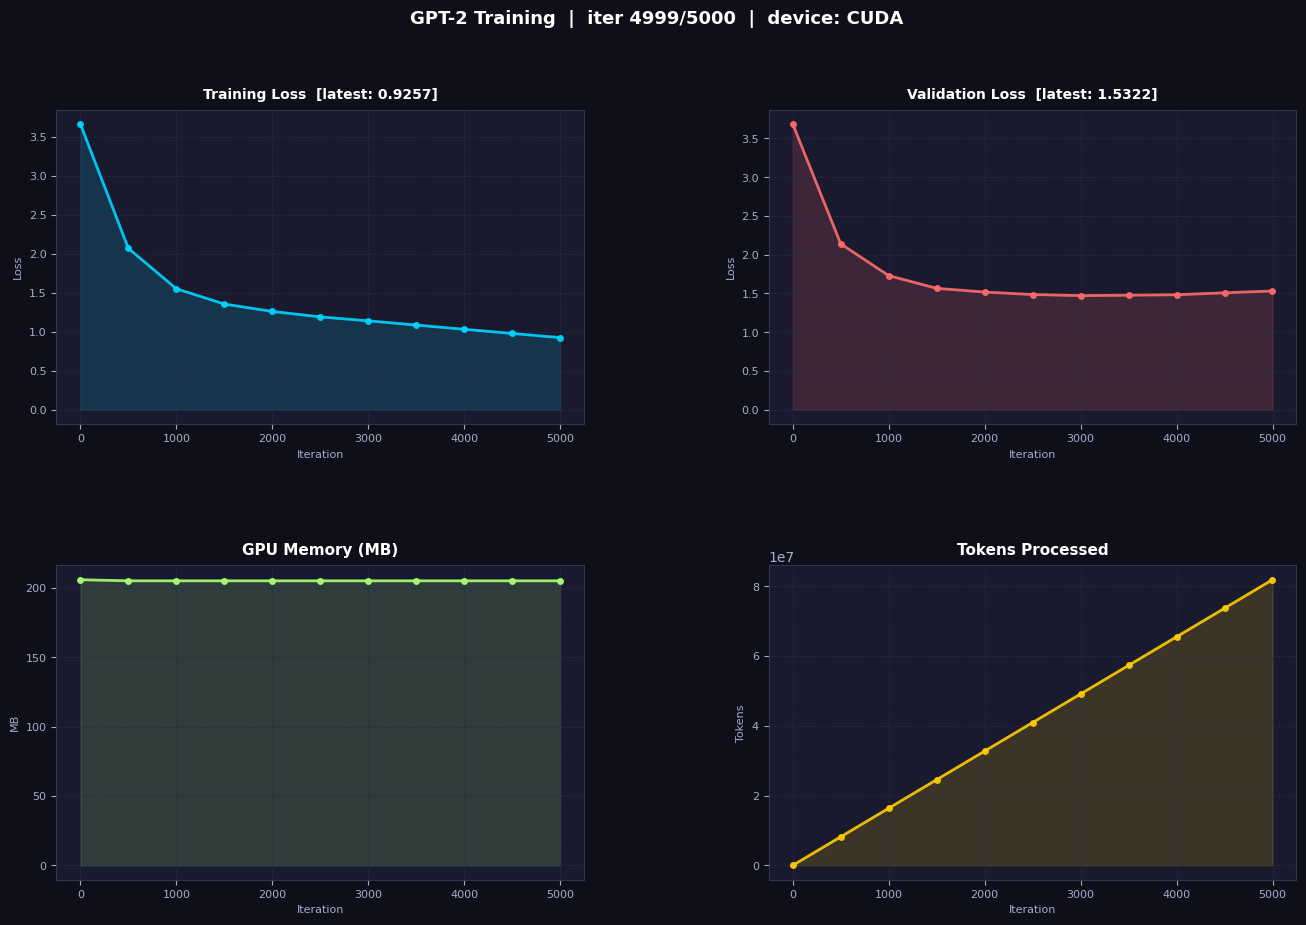

────────────────────────────────────────────────────────────

✅ Training complete!
Total time       : 67.4 min
Total tokens     : 81,920,000
Final train loss : 0.9257
Final val loss   : 1.5322


In [10]:
# -----------------------------------------------
# Cell 10: Training loop
# -----------------------------------------------
train_losses   = []
val_losses     = []
iters_log      = []
memories       = []   # GPU memory in MB
tokens_log     = []   # cumulative tokens processed
tokens_processed = 0

tokens_per_batch = batch_size * block_size
t0 = time.time()

print(f'Starting training for {max_iters} iterations...')
print(f'Tokens per batch : {tokens_per_batch:,}')
print(f'Eval every       : {eval_interval} iters')
print('─' * 60)

for iter in range(max_iters):

    # ── forward + backward ──────────────────────
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    tokens_processed += tokens_per_batch

    # ── eval & log ──────────────────────────────
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()

        mem_mb = torch.cuda.memory_allocated() / 1e6 if device == 'cuda' else 0.0
        elapsed = time.time() - t0
        tokens_per_sec = tokens_processed / elapsed

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        iters_log.append(iter)
        memories.append(mem_mb)
        tokens_log.append(tokens_processed)

        print(
            f'iter {iter:>5} | '
            f'train loss: {losses["train"]:.4f} | '
            f'val loss: {losses["val"]:.4f} | '
            f'mem: {mem_mb:.0f} MB | '
            f'tokens: {tokens_processed:>10,} | '
            f'tok/s: {tokens_per_sec:,.0f}'
        )

        # live plot update
        plot_metrics(iters_log, train_losses, val_losses, memories, tokens_log)

total_time = time.time() - t0
print('─' * 60)
print(f'\n✅ Training complete!')
print(f'Total time       : {total_time/60:.1f} min')
print(f'Total tokens     : {tokens_processed:,}')
print(f'Final train loss : {train_losses[-1]:.4f}')
print(f'Final val loss   : {val_losses[-1]:.4f}')

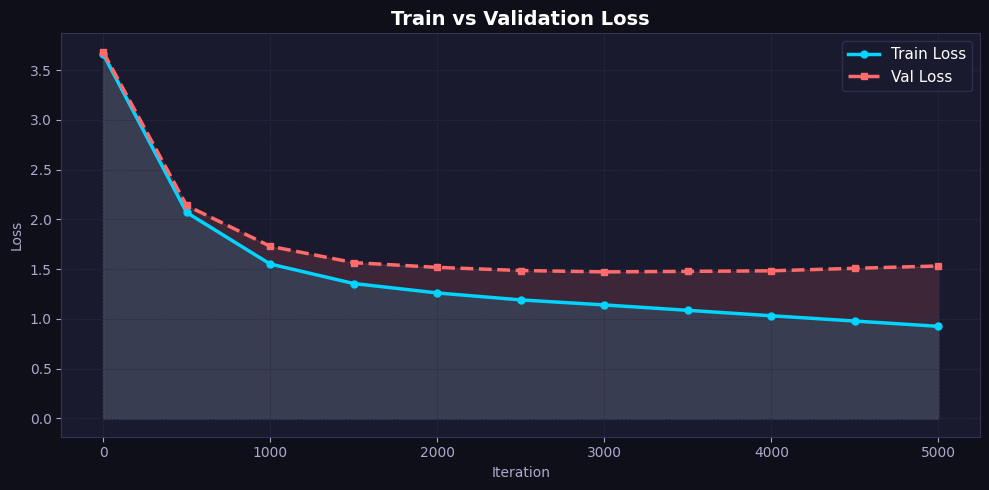


📊 Saved: final_loss_curve.png


In [11]:
# -----------------------------------------------
# Cell 11: Final combined loss plot
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')
for spine in ax.spines.values():
    spine.set_color('#333355')
ax.tick_params(colors='#aaaacc')

ax.plot(iters_log, train_losses, color='#00d4ff', linewidth=2.5,
        marker='o', markersize=5, label='Train Loss')
ax.plot(iters_log, val_losses,   color='#ff6b6b', linewidth=2.5,
        marker='s', markersize=5, label='Val Loss',   linestyle='--')
ax.fill_between(iters_log, train_losses, alpha=0.15, color='#00d4ff')
ax.fill_between(iters_log, val_losses,   alpha=0.15, color='#ff6b6b')

ax.set_title('Train vs Validation Loss', color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Iteration', color='#aaaacc')
ax.set_ylabel('Loss',      color='#aaaacc')
ax.grid(True, color='#2a2a4a', linewidth=0.5, linestyle='--')
legend = ax.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('final_loss_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('\n📊 Saved: final_loss_curve.png')

In [12]:
# -----------------------------------------------
# Cell 12: Generate sample text
# -----------------------------------------------
model.eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = decode(model.generate(context, max_new_tokens=500)[0].tolist())

print('=' * 60)
print('📝 GENERATED TEXT')
print('=' * 60)
print(generated)
print('=' * 60)

📝 GENERATED TEXT


JULIET:
Good my lord, I hope, prithee, in thee, of great lads.
God keep thy summer day with a honey wench,
Where shall I enjoy discontented either looks,
Why, puts lay no justice and spectacle lost
The officer to see thy stones; but 
Where never be in the king for any Bianca satisfied,
Enjoy it thy tongue; but stands at thy griefs to breathe
The slew not for these of our tenderness the ground.
Now, Sir Ratclifford, redeem them to Breck?

EDWARD:
Farewell, lords, to throw me a council-house;
Who
